In [682]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [683]:
import os
import uuid

def rename_raw_images(base_path="images"):
    for folder in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder)

        if not os.path.isdir(folder_path):
            continue

        if folder.lower() == "cropped":
            continue

        print(f"Renaming images in: {folder}")

        image_files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".jfif"))
        ]

        image_files.sort()

        # STEP 1: rename to temporary unique names
        temp_names = {}
        for file in image_files:
            old_path = os.path.join(folder_path, file)
            ext = os.path.splitext(file)[1]
            temp_name = f"__temp_{uuid.uuid4().hex}{ext}"
            temp_path = os.path.join(folder_path, temp_name)
            os.rename(old_path, temp_path)
            temp_names[temp_name] = ext

        # STEP 2: rename to final names
        for i, temp_name in enumerate(sorted(temp_names), start=1):
            temp_path = os.path.join(folder_path, temp_name)
            new_filename = f"{folder}_{i}{temp_names[temp_name]}"
            new_path = os.path.join(folder_path, new_filename)
            os.rename(temp_path, new_path)

        print(f"  → Renamed {len(image_files)} files.\n")

rename_raw_images("./images")


Renaming images in: Courtois
  → Renamed 316 files.

Renaming images in: Cristiano Ronaldo
  → Renamed 301 files.

Renaming images in: Dybala
  → Renamed 305 files.

Renaming images in: Kross
  → Renamed 301 files.

Renaming images in: Lionel Messi
  → Renamed 337 files.

Renaming images in: Mohamed Salah
  → Renamed 317 files.

Renaming images in: Neymar
  → Renamed 69 files.

Renaming images in: Pogba
  → Renamed 302 files.



In [684]:
img = cv2.imread(r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\test_images\Human1.png")
img.shape

(391, 368, 3)

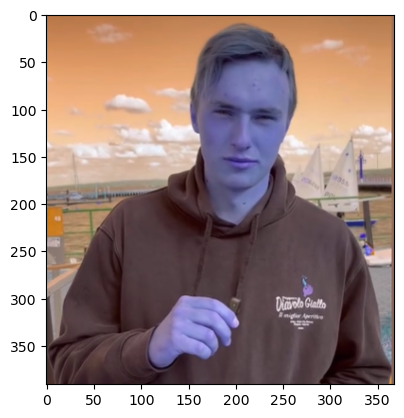

In [685]:
plt.imshow(img)

In [686]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(391, 368)

In [687]:
gray

array([[111, 111, 111, ..., 113, 113, 112],
       [111, 111, 111, ..., 114, 113, 112],
       [111, 111, 111, ..., 114, 113, 113],
       ...,
       [ 47,  47,  48, ..., 118, 100, 104],
       [ 47,  47,  48, ..., 117, 100, 104],
       [ 47,  47,  48, ..., 116, 100, 103]], dtype=uint8)

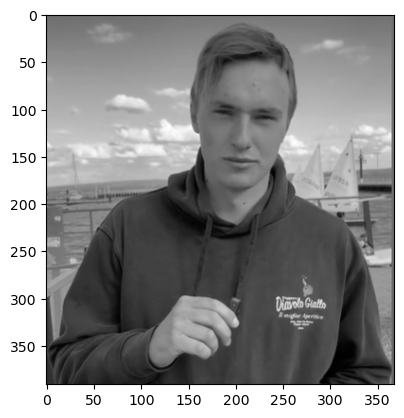

In [688]:
plt.imshow(gray, cmap='gray')

In [689]:
img2 = cv2.imread(r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\test_images\test4.jpg")

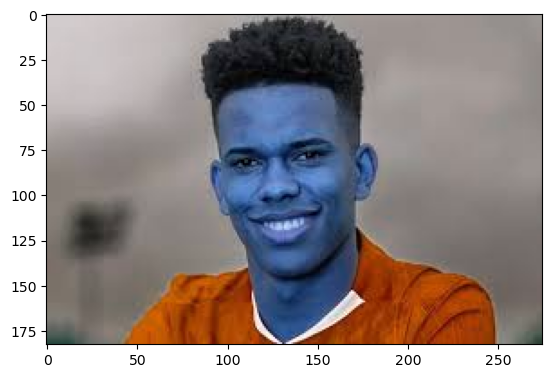

In [690]:
plt.imshow(img2)

In [691]:
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray2

array([[205, 205, 205, ..., 152, 152, 152],
       [205, 205, 205, ..., 152, 152, 152],
       [205, 205, 205, ..., 151, 151, 151],
       ...,
       [ 75,  75,  75, ...,  67,  67,  66],
       [ 70,  70,  70, ...,  63,  62,  62],
       [ 65,  65,  65, ...,  61,  60,  60]], dtype=uint8)

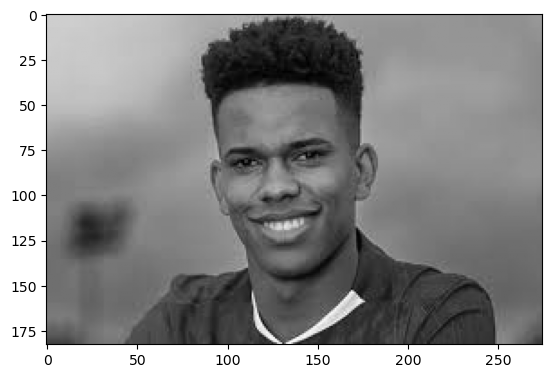

In [692]:
plt.imshow(gray2, cmap = 'gray')

In [693]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[146,  58, 127, 127]])

In [694]:
(x,y,w,h) = faces[0]
x,y,w,h

(146, 58, 127, 127)

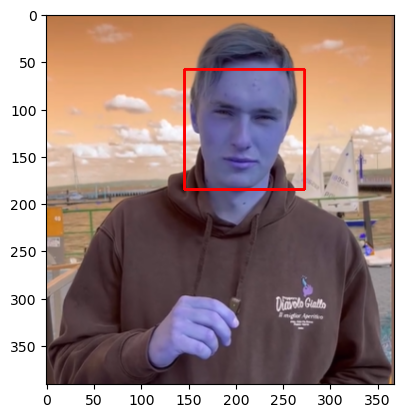

In [695]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

In [696]:
faces_2 = face_cascade.detectMultiScale(gray2, 1.3, 5)
faces_2

array([[ 78,  41, 100, 100]])

In [697]:
(x,y,w,h) = faces_2[0]
x,y,w,h

(78, 41, 100, 100)

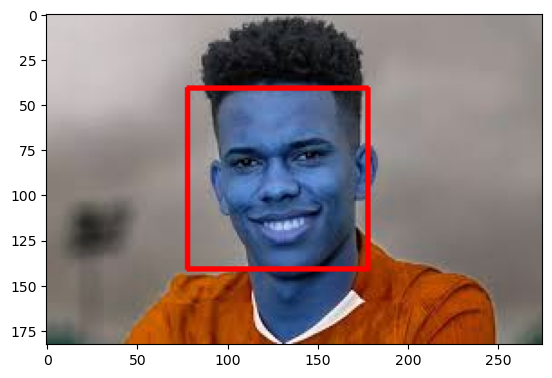

In [698]:
face_img_2 = cv2.rectangle(img2,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img_2)

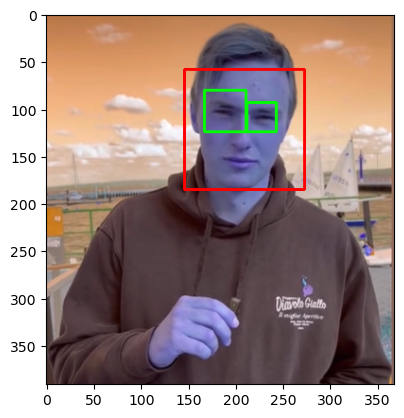

In [699]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h,x:x+w]
    roi_color = face_img[y:y+h,x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()


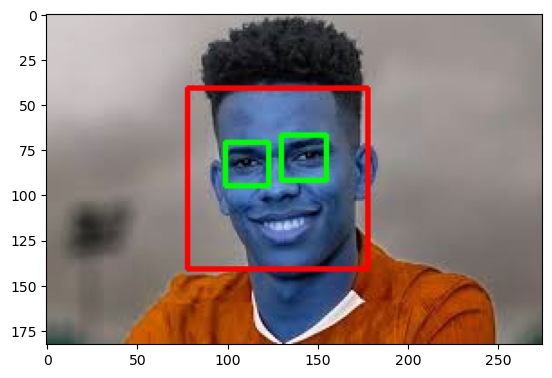

In [700]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces_2:
    face_img2 = cv2.rectangle(img2,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray2 = gray2[y:y+h,x:x+w]
    roi_color2 = face_img2[y:y+h,x:x+w]
    eyes2 = eye_cascade.detectMultiScale(roi_gray2)
    for (ex,ey,ew,eh) in eyes2:
        cv2.rectangle(roi_color2,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(face_img2, cmap='gray')
plt.show()


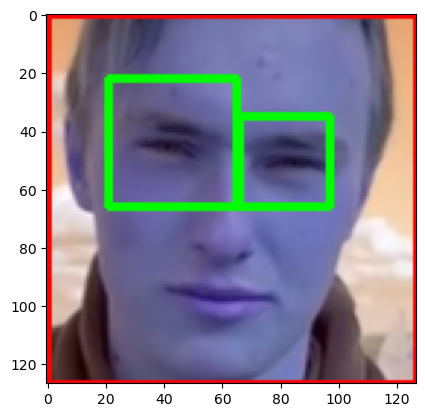

In [701]:
%matplotlib inline
plt.imshow(roi_color, cmap = 'gray')

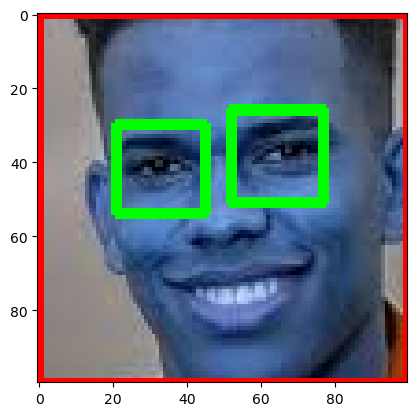

In [702]:
%matplotlib inline
plt.imshow(roi_color2, cmap='gray')

In [703]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Could not read image:", image_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray,1.3,5)

    for (x,y,w,h) in faces:
        roi = img[y:y+h, x:x+w]
        return roi

    return None


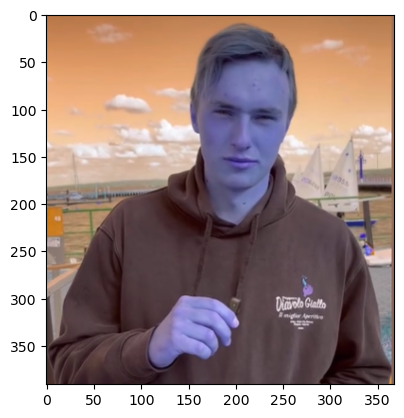

In [704]:
original_image = cv2.imread(r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\test_images\Human1.png")
plt.imshow(original_image)

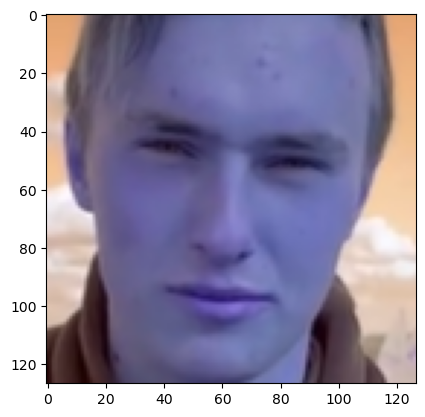

In [705]:
cropped_image = get_cropped_image_if_2_eyes(r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\test_images\Human1.png")
plt.imshow(cropped_image)

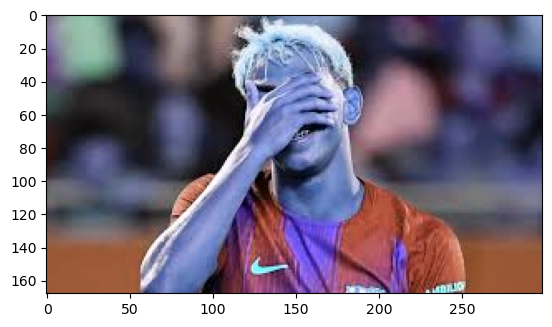

In [706]:
obstructed_image = cv2.imread(r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\test_images\test7.jpg")
plt.imshow(obstructed_image)

In [707]:
cropped_image_no = get_cropped_image_if_2_eyes(r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\test_images\test7.jpg")
cropped_image_no

In [708]:
path_to_data = r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images"
path_to_cr_data = r"C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images\cropped"


In [709]:
import os

img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir() and entry.name != "cropped":
        img_dirs.append(entry.path)


In [710]:
img_dirs

['C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Courtois',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Cristiano Ronaldo',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Dybala',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Kross',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Lionel Messi',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Mohamed Salah',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Neymar',
 'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\Pogba']

In [711]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [712]:
cropped_image_dirs = []
celebrity_file_names_dict = {}
for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('\\')[-1]
    celebrity_file_names_dict[celebrity_name] = []
    print(celebrity_name)
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + "/cropped_" + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

Courtois
Generating cropped images in folder:  C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images\cropped/cropped_Courtois
Cristiano Ronaldo
Generating cropped images in folder:  C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images\cropped/cropped_Cristiano Ronaldo
Dybala
Generating cropped images in folder:  C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images\cropped/cropped_Dybala
Kross
Generating cropped images in folder:  C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images\cropped/cropped_Kross
Lionel Messi
Generating cropped images in folder:  C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image Classification\model\images\cropped/cropped_Lionel Messi
Mohamed Salah
Generating cropped images in folder:  C:\Users\DELL\Desktop\MACHINE LEARNING\Projects\Sport Celebrities Image 

In [713]:
import numpy as np
import pywt
import cv2
def w2d(img, mode='haar', level=1):
    imArray = img
    imArray = cv2.cvtColor(imArray,cv2.COLOR_RGB2GRAY)
    imArray = np.float32(imArray)
    imArray /= 255;
    coeffs = pywt.wavedec2(imArray, mode, level = level)
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0;

    imArray_H = pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H = np.uint8(imArray_H)

    return imArray_H

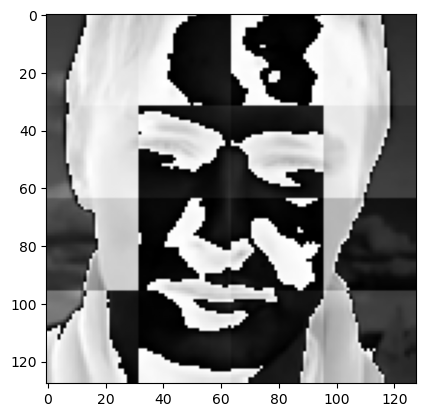

In [714]:
im_har = w2d(cropped_image, 'db1',5)
plt.imshow(im_har, cmap='gray')

In [715]:
celebrity_file_names_dict

{'Courtois': ['C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\cropped/cropped_Courtois/Courtois1.png',
  'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\cropped/cropped_Courtois/Courtois2.png',
  'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\cropped/cropped_Courtois/Courtois3.png',
  'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\cropped/cropped_Courtois/Courtois4.png',
  'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\cropped/cropped_Courtois/Courtois5.png',
  'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebrities Image Classification\\model\\images\\cropped/cropped_Courtois/Courtois6.png',
  'C:\\Users\\DELL\\Desktop\\MACHINE LEARNING\\Projects\\Sport Celebri

In [716]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'Courtois': 0,
 'Cristiano Ronaldo': 1,
 'Dybala': 2,
 'Kross': 3,
 'Lionel Messi': 4,
 'Mohamed Salah': 5,
 'Neymar': 6,
 'Pogba': 7}

In [717]:
X = []
y = []

for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (32,32))
        img_har = w2d(img, 'db1', 3)
        scalled_img_har = cv2.resize(img_har, (32,32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1), scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [718]:
len(X[0])

4096

In [719]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(1172, 4096)

In [720]:
X[0]

array([223., 221., 222., ...,   0.,   0.,   0.])

In [721]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42)
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)


0.7617021276595745

In [722]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.64      0.58      0.61        36
           2       0.63      0.83      0.72        35
           3       0.88      0.85      0.87        53
           4       0.68      0.54      0.60        28
           5       0.85      1.00      0.92        22
           6       1.00      0.33      0.50         9
           7       0.67      0.73      0.70        11

    accuracy                           0.76       235
   macro avg       0.78      0.72      0.72       235
weighted avg       0.77      0.76      0.76       235



In [723]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import pandas as pd


In [724]:
model_params = {
    'svm': {
        'model': svm.SVC(probability=True),
        'params': {
            'svc__C': [0.1, 1, 10, 100],
            'svc__kernel': ['linear', 'rbf'],
            'svc__gamma': ['scale', 'auto'],
            'svc__class_weight': [None, 'balanced']
        }
    },

    'random_forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'randomforestclassifier__n_estimators': [100, 200],
            'randomforestclassifier__max_depth': [None, 20, 30],
            'randomforestclassifier__min_samples_split': [2, 5],
            'randomforestclassifier__min_samples_leaf': [1, 2]
        }
    },

    'logistic_regression': {
        'model': LogisticRegression(max_iter=1000, solver='saga'),
        'params': {
            'logisticregression__C': [0.01, 0.1, 1, 10],
            'logisticregression__penalty': ['l1', 'l2'],
            'logisticregression__class_weight': [None, 'balanced']
        }
    }
}


In [725]:
scores = []
best_estimators = {}

from sklearn.model_selection import RandomizedSearchCV

for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])

    clf = RandomizedSearchCV(
    pipe,
    mp['params'],
    n_iter=15,
    cv=3,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

    clf.fit(X_train, y_train)

    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores)
df


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\DELL\miniconda3\envs\ml_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model,best_score,best_params
0,svm,0.826070,"{'svc__kernel': 'linear', 'svc__gamma': 'scale..."
1,random_forest,0.715068,"{'randomforestclassifier__n_estimators': 200, ..."
2,logistic_regression,0.834596,"{'logisticregression__penalty': 'l1', 'logisti..."


In [726]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc', SVC(C=100, kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(max_depth=20, min_samples_leaf=2,
                                         n_estimators=200, random_state=42))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=10, class_weight='balanced',
                                     max_iter=1000, penalty='l1',
                                     solver='saga'))])}

In [727]:
best_estimators['svm'].score(X_test, y_test)

0.8382978723404255

In [728]:

best_estimators['random_forest'].score(X_test, y_test)

0.6680851063829787

In [729]:
best_estimators['logistic_regression'].score(X_test, y_test)

0.8170212765957446

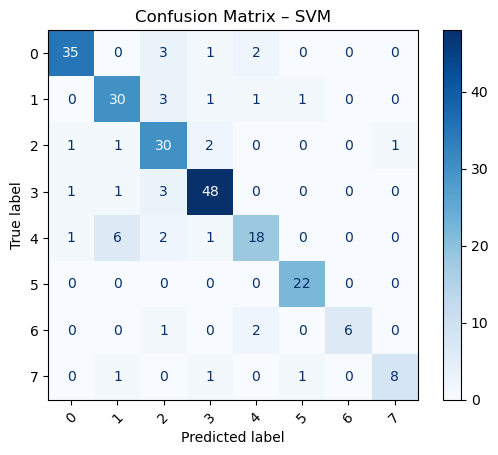

In [733]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
y_pred = best_estimators['svm'].predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix – SVM")
plt.show()


In [738]:
from sklearn.metrics import classification_report

# Predict with best SVM
y_pred = best_estimators['svm'].predict(X_test)

# If you want class names instead of numbers
labels = list(class_dict.keys())

print(
    classification_report(
        y_test,
        y_pred,
        target_names=labels
    )
)


                   precision    recall  f1-score   support

         Courtois       0.92      0.85      0.89        41
Cristiano Ronaldo       0.77      0.83      0.80        36
           Dybala       0.71      0.86      0.78        35
            Kross       0.89      0.91      0.90        53
     Lionel Messi       0.78      0.64      0.71        28
    Mohamed Salah       0.92      1.00      0.96        22
           Neymar       1.00      0.67      0.80         9
            Pogba       0.89      0.73      0.80        11

         accuracy                           0.84       235
        macro avg       0.86      0.81      0.83       235
     weighted avg       0.84      0.84      0.84       235



In [739]:
best_clf = best_estimators['svm']
class_dict

{'Courtois': 0,
 'Cristiano Ronaldo': 1,
 'Dybala': 2,
 'Kross': 3,
 'Lionel Messi': 4,
 'Mohamed Salah': 5,
 'Neymar': 6,
 'Pogba': 7}

In [740]:
import joblib
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

In [742]:
import json
with open("class_dictionary.json", "w") as f:
    f.write(json.dumps(class_dict))